In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Configuração inicial

In [7]:
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

# 1. Modelagem do Sensor 

Simulação do "Tempo Contínuo"

In [8]:
t_cont = np.linspace(0, 1, 10000)

Sinal físico real s(t)

In [9]:
f_sinal = 5.0 #  Frequência -> Hz
s_t = np.sin(2 * np.pi * f_sinal * t_cont)

Sinal lido pelo sensor com ruído x(t) = s(t) + e(t)

In [10]:
ruido_interferencia = 0.5 * np.sin(2 * np.pi * 50 * t_cont) 
ruido_branco = 0.2 * np.random.randn(len(t_cont))
x_t = s_t + ruido_interferencia + ruido_branco

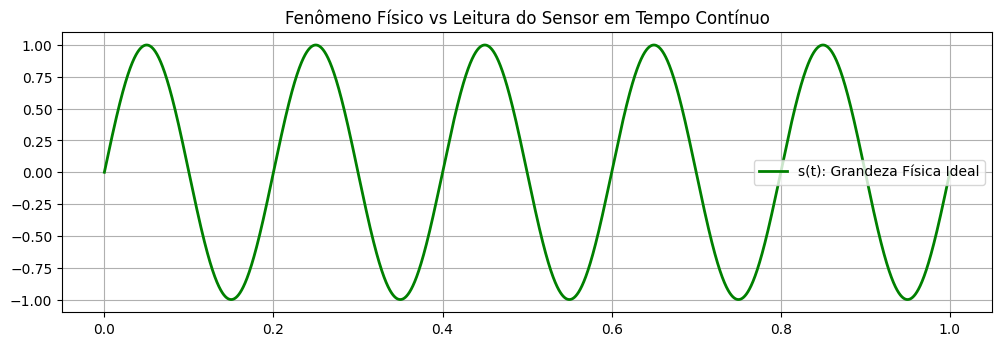

In [11]:
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(t_cont, s_t, 'g', linewidth=2, label='s(t): Grandeza Física Ideal')
plt.title('Fenômeno Físico vs Leitura do Sensor em Tempo Contínuo')
plt.legend()

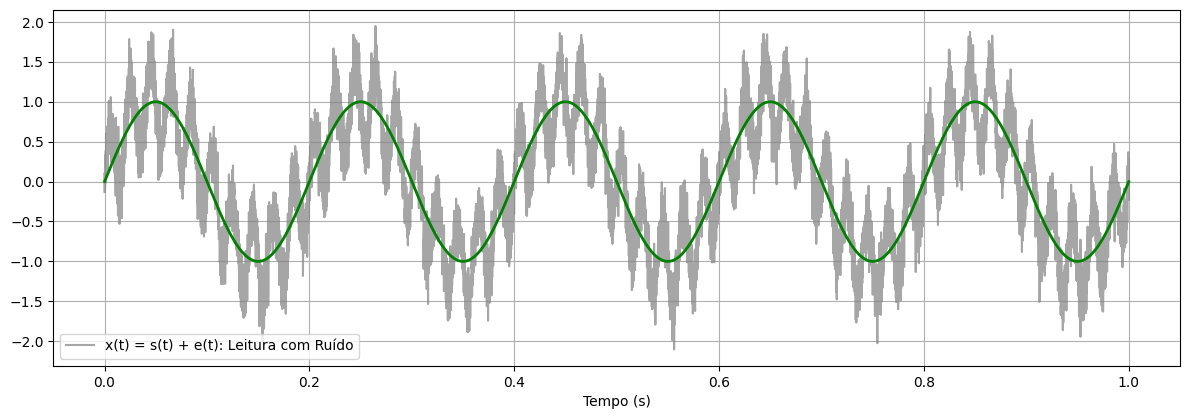

In [12]:
plt.subplot(2, 1, 2)
plt.plot(t_cont, x_t, 'gray', alpha=0.7, label='x(t) = s(t) + e(t): Leitura com Ruído')
plt.plot(t_cont, s_t, 'g', linewidth=2)
plt.xlabel('Tempo (s)')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Amostragem e o Teorema de Nyquist

In [13]:
fs_adequada = 200 
Ts_adequada = 1.0 / fs_adequada
n_adequada = np.arange(0, 1, Ts_adequada)

Extraindo amostras do sinal x(t)  

Equivalente computacional ao conversor A/D (Analog-to-Digital)

In [14]:
x_n = np.sin(2 * np.pi * f_sinal * n_adequada) + \
      0.5 * np.sin(2 * np.pi * 50 * n_adequada) + \
      0.2 * np.random.randn(len(n_adequada))

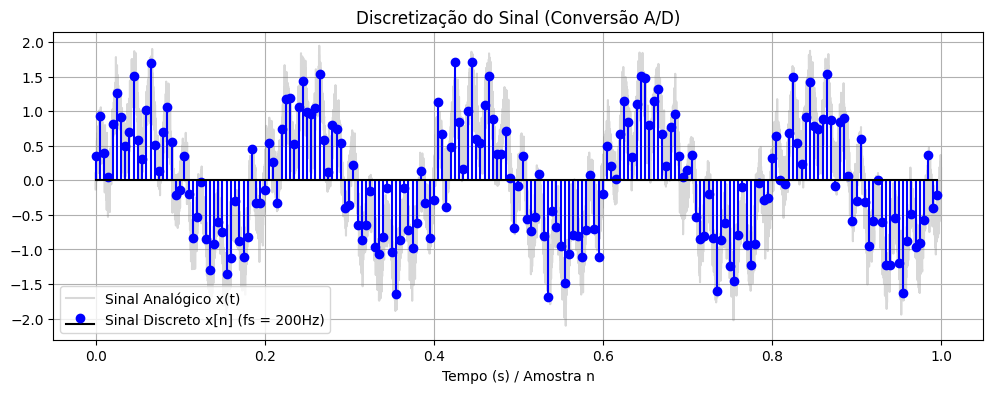

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(t_cont, x_t, 'gray', alpha=0.3, label='Sinal Analógico x(t)')
plt.stem(n_adequada, x_n, linefmt='b-', markerfmt='bo', basefmt='k-', label='Sinal Discreto x[n] (fs = 200Hz)')
plt.title('Discretização do Sinal (Conversão A/D)')
plt.xlabel('Tempo (s) / Amostra n')
plt.legend()
plt.show()

# Processamento em Sistema Discreto (Filtro FIR Causal)

Projeto de um filtro FIR Passa-Baixa LTI Causal

In [ ]:
ordem_filtro = 30
frequencia_corte = 15.0 
f_nyq = fs_adequada / 2.0 

Coeficientes do filtro (Resposta ao Impulso h[n])

In [17]:
h_n = signal.firwin(ordem_filtro, frequencia_corte / f_nyq)

Processamento do sinal: Convolução discreta entre x[n] e h[n]

y[n] = x[n] * h[n]

In [18]:
y_n = signal.lfilter(h_n, 1.0, x_n)

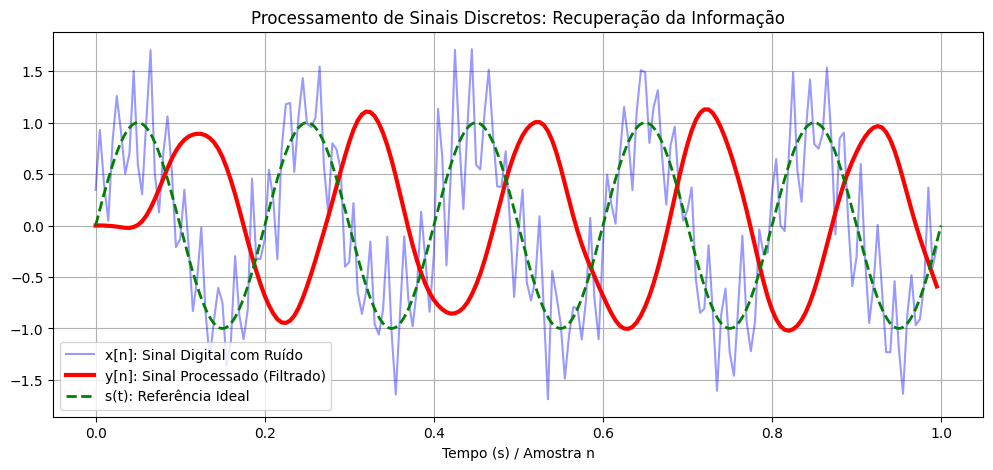

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(n_adequada, x_n, 'b', alpha=0.4, label='x[n]: Sinal Digital com Ruído')
plt.plot(n_adequada, y_n, 'r', linewidth=3, label='y[n]: Sinal Processado (Filtrado)')
plt.plot(t_cont, s_t, 'g--', linewidth=2, label='s(t): Referência Ideal')
plt.title('Processamento de Sinais Discretos: Recuperação da Informação')
plt.xlabel('Tempo (s) / Amostra n')
plt.legend()
plt.show()